# 0. 实验说明

本实验的主要内容为:  
使用一种名为 [DistilBERT](https://arxiv.org/abs/1910.01108) 的 BERT 变体来自动识别人们在 Twitter 上发布文本的情绪状态.    
对应教材: Natural Language Processing (Lewis Tunstall, Leandro von Werra etc.)  
原代码仓库: [nlp-with-transformers/notebooks](https://github.com/nlp-with-transformers/notebooks)

实验基础代码可参见 `HW2/project.ipynb`.  
你需要保证自己在熟悉了基础代码后，完成以下任务 (已标记为 `TODO`):

1. 创建一个 `token2idx` 字典，将字符 (key) 映射为整数 (value)，用于实现字符级别的标记化操作;
2. 完善提取隐藏层 `[CLS]` 特征的函数;
3. 使用 `Scikit-Learn` 库中的不同分类模型对提取的特征进行分类，并比较不同模型的分类效果;
4. 调整模型参数，以训练出更高分类准确率的模型，探讨不同参数设置对模型训练效果的影响;
5. 分析分类错误的样本为什么会被分错，分类正确的样本为什么会被分对;
6. 生成 5 个对抗样本，尽可能让你的模型无法正确判断其情感类别，并尝试解释其中的原因.

提交内容: 源代码、HuggingFace 模型地址、实验报告  
报告要求四页左右，内容包括摘要、引言、方法、实验以及总结部分.

****

文本分类是自然语言处理中最常见的任务之一，   
它可用于各种应用程序，例如将客户反馈标记为不同类别.   
很可能你的垃圾邮件过滤器正在使用文本分类来保护你的收件箱免受垃圾邮件的困扰!

另一种常见的文本分类是情感分析，它旨在确定给定文本的情感.  
例如，像 Tesla 这样的公司可能会分析 Twitter 上的帖子，以确定人们是否喜欢它的新车顶.

<img alt="Tesla Tweet" width="500" caption="Analyzing Twitter content can yield useful feedback from customers (courtesy of Aditya Veluri)" src="images/chapter02_tweet.png" id="tesla-tweet"/>

假设我们需要构建一个系统，可以自动识别人们在 Twitter 上对某一产品表达的情绪状态.  
在这一章中，我们将使用一种名为 DistilBERT 的 BERT 变体来解决这个任务.  
这个模型的主要优势在于它能够达到与 BERT 相媲美的性能，同时体积更小，这使我们能够在几分钟内训练出一个分类器.

<img alt="Hugging Face Pipeline" width="700" caption="A typical pipeline for training transformer models with the image:images/logo.png[hf,13,13] Datasets, image:images/logo.png[hf,13,13] Tokenizers, and image:images/logo.png[hf,13,13] Transformers libraries" src="images/chapter02_hf-libraries.png" id="hf-libraries"/>

In [1]:
from utils import *
setup_chapter()

GPU was detected! This notebook can be very fast with a GPU 🐰
Using transformers v4.51.3
Using datasets v3.6.0


# 1. 数据集
## 1.1 `Dataset` 类

为了构建我们的情感检测器，我们将使用 [CARER](http://dx.doi.org/10.18653/v1/D18-1404) 数据集.  
与大多数情感分析数据集不同，这个数据集包含六种基本情感: 愤怒、厌恶、恐惧、喜悦、悲伤和惊讶.

让我们用 `load_dataset()` 函数加载 `emotion` 目录中的数据集，  
得到的 `emotions` 对象是 `Dataset` 类的一个实例，类似于一个 Python 字典，每个键对应不同的分割:

In [2]:
from datasets import load_dataset

emotions = load_dataset("emotion")
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

我们可以使用通常的字典语法来访问单个分割:

In [3]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

`Dataset` 对象的行为类似于普通的 Python 数组或列表，因此我们可以查询它的长度:

In [4]:
len(train_ds)

16000

或者通过它的索引来访问单个示例:

In [5]:
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

在这里，我们可以看到一行数据被表示为一个字典，其中键对应于列名, 值是文本和情感:

In [6]:
train_ds.column_names

['text', 'label']

我们可以通过访问 `Dataset` 对象的 `features` 属性来看到底层使用的数据类型:

In [7]:
print(train_ds.features)

{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness',
'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}


在这种情况下，`text` 列的数据类型是 `string`，  
而 `label` 列是一个特殊的 `ClassLabel` 对象，其中包含有关类别名称及其与整数的映射信息.  
我们还可以用切片访问若干行数据 (此时字典的值是列表而不是单个元素):

In [8]:
print(train_ds[:5])

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so
damned hopeful just from being around someone who cares and is awake', 'im
grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic
about the fireplace i will know that it is still on the property', 'i am feeling
grouchy'], 'label': [0, 0, 3, 2, 3]}


我们还可以按名称获取整列:

In [9]:
print(train_ds["text"][:5])

['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned
hopeful just from being around someone who cares and is awake', 'im grabbing a
minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the
fireplace i will know that it is still on the property', 'i am feeling grouchy']


现在我们已经看到了如何使用 `datasets` 库加载和检查数据，让我们对文本内容进行一些健全性检查.

## 1.2 从 Datasets 到 DataFrames

我们通常将 `Dataset` 对象转换为 Pandas `DataFrame`，以便使用高级 API 来进行数据可视化.  
为了实现转换，`datasets` 库提供了 `set_format()` 方法，允许我们更改数据集的输出格式.

In [10]:
import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


其中列标题 `text` 和 `label` 被保留.  
然而，`label` 列表示为整数，我们可以使用标签特征的 `int2str()` 方法，  
在我们的 DataFrame 中创建一个新列，其中包含相应的标签名称:

In [11]:
def label_int2str(row):
    """Map a label integer to its corresponding class name string."""
    return emotions["train"].features["label"].int2str(row)

# Create a new column with human-readable label names
df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


在开始构建分类器之前，让我们仔细研究一下数据集.  
正如 Andrej Karpathy 在 ["A Recipe for Training Neural Networks"](https://karpathy.github.io/2019/04/25/recipe) 中所指出的，  
与数据成为 "一体" 是训练优秀模型的重要步骤！

## 1.3 查看数据的分布

当你在处理文本分类问题时，检查一下各类别的分布是个好主意.  
相对于一个类别分布均衡的数据集来说，一个类别分布不均的数据集需要在训练损失和评估指标方面进行额外处理.  
通过 `pandas` 和 `matplotlib` 库，我们可以快速可视化类别分布，如下所示:

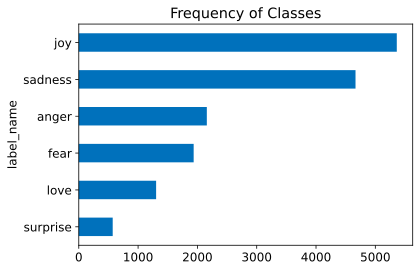

In [12]:
import matplotlib.pyplot as plt

# Plot the frequency of each emotion class in the training set
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

在这种情况下，我们可以看到数据集严重不平衡.  
`joy` 和 `sadness` 类别经常出现，而 `love` 和 `surprise` 相对少见.   
处理不平衡数据的几种方法，包括:
- 随机过采样少数类别;
- 随机欠采样多数类别;
- 从代表少数类别的样本中收集更多数据.
更多采样技术参见 [Imbalanced-learn library](https://imbalanced-learn.org/stable/).

简单起见，我们将使用原始的、类别分布不均衡的数据集.  
现在我们已经看过类别，让我们来看看数据集里的 tweets 本身.

## 1.4 我们的推文有多长?

Transformer 模型具有最大输入序列长度，称为 "最大上下文大小".  
对于使用 DistilBERT 的应用程序，最大上下文大小为 512 个 token，相当于几段文本.  
正如我们将在下一节中看到的，一个 token 是文本的一个原子部分.  
我们可以通过查看每种情感的推文长度的单词分布来粗略估计推文长度：

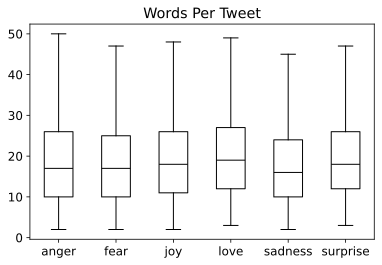

In [13]:
# Compute word count per tweet and visualise the distribution by emotion class
df["Words Per Tweet"] = df["text"].str.split().apply(len)
df.boxplot("Words Per Tweet", by="label_name", grid=False, showfliers=False, color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

从情感上看，我们可以看到对于每种情绪，大多数推文大约在 15 个单词左右，  
最长的推文远远在 DistilBERT 的最大上下文大小以下.  
如果文本超过模型的上下文大小，需要对其进行截断，这可能会导致性能下降.  

现在我们要考虑如何将这些原始文本转换为适合 Transformers 的格式.  
此外，我们也要重置数据集的输出格式，因为我们不再需要 DataFrame 格式了.

In [14]:
emotions.reset_format()

# 2. 从 Text 到 Tokens

Transformer 模型如 DistilBERT 不能接收原始字符串作为输入;  
它们假定文本已经被 tokenized 并 encoded 为数值向量.  
Tokenization 是将字符串分解为模型中使用的原子单位的步骤.  
Tokenization 策略有很多种.

## 2.1 Character Tokenization

最简单的 tokenization 策略是将每个字符作为一个 token.  
在 Python 中，`str` 对象在底层实际上是数组，  
这使我们能够仅用一行代码快速实现基于字符级别的 tokenization:

In [15]:
text = "Tokenizing text is a core task of NLP."
tokenized_text = list(text)
print(tokenized_text)

['T', 'o', 'k', 'e', 'n', 'i', 'z', 'i', 'n', 'g', ' ', 't', 'e', 'x', 't', ' ',
'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o',
'f', ' ', 'N', 'L', 'P', '.']


这是一个不错的开始，但还没有完成.  
我们的模型期望将每个字符转换为一个整数.  
一个简单的方法是使用一个独一无二的整数对每个唯一的 token 进行编码:

In [16]:
#TODO (No.1): 将字符 (key) 转化为整数 (value) 的天然的对应 python 的字典 dict 操作，尝试写一个 token2idx 字典
# Build a mapping from each unique character to a unique integer ID,
# sorted by ASCII/Unicode code point
token2idx = {ch: i for i, ch in enumerate(sorted(set(tokenized_text)))}
print(token2idx)

{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9,
'g': 10, 'i': 11, 'k': 12, 'n': 13, 'o': 14, 'r': 15, 's': 16, 't': 17, 'x': 18,
'z': 19}


这为我们提供了一个从词汇表中的每个字符到唯一整数的映射.  
现在我们可以使用 `token2idx` 将 tokenized 文本转换为整数列表：

In [17]:
input_ids = [token2idx[token] for token in tokenized_text]
print(input_ids)

[5, 14, 12, 8, 13, 11, 19, 11, 13, 10, 0, 17, 8, 18, 17, 0, 11, 16, 0, 6, 0, 7,
14, 15, 8, 0, 17, 6, 16, 12, 0, 14, 9, 0, 3, 2, 4, 1]


每个 token 现在都映射到了一个唯一的数字标识符 (因此称为 `input_ids`).  
最后一步是将 `input_ids` 转换为一个 one-hot 的二维张量.    
One-hot 向量经常用于机器学习中对分类数据进行编码.  
例如，假设我们想要对 *Transformers* 电影中角色的名字进行编码.  
一种方法是将每个名字映射到一个唯一的 ID，如下所示:

In [18]:
categorical_df = pd.DataFrame(
    {"Name": ["Bumblebee", "Optimus Prime", "Megatron"], "Label ID": [0,1,2]})
categorical_df

,Name,Label ID
0,Bumblebee,0
1,Optimus Prime,1
2,Megatron,2


这种方法的问题在于它在名称之间创造了一个虚构的顺序，而神经网络非常擅长学习这类关系.  
因此，我们可以为每个类别创建一个新列，并在该类别为真时分配一个 1，在其他情况下分配一个 0.  
在 Pandas 中，可以使用 `get_dummies()` 函数来实现这一点，方法如下:

In [19]:
pd.get_dummies(categorical_df["Name"])

,Bumblebee,Megatron,Optimus Prime
0,True,False,False
1,False,False,True
2,False,True,False


这个`DataFrame`的行是 one-hot 向量，其中有一个 hot 条目为 1，其他地方都是 0.  

下面我们可以通过将 `input_ids` 转换为 tensor,   
并应用 `one_hot()` 函数来在 PyTorch 中创建 one-hot 编码，如下所示:

In [20]:
input_ids = torch.tensor(input_ids)
one_hot_encodings = torch.nn.functional.one_hot(input_ids, num_classes=len(token2idx))
one_hot_encodings.shape

torch.Size([38, 20])

对于这 38 个输入标识符，我们现在有一个 20 维的独热向量，因为我们的词汇表包含 20 个独特字符.

> 警告: 在 `one_hot()` 函数中需要设置 `num_classes`，避免 one-hot 向量的长度比词汇表短.

通过检查第一个向量，我们可以验证在由 `input_ids[0]` 指示的位置上出现了 1:

In [21]:
print(f"Token: {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"One-hot: {one_hot_encodings[0]}")

Token: T
Tensor index: 5
One-hot: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


从上述例子中，我们可以看到字符级 tokenization 忽略了文本中的结构，将整个字符串视为字符流.   
虽然这有助于处理拼写错误和罕见单词，  
但缺点是语言结构 (如单词) 需要从数据中学习，这需要大量的计算、内存和数据.   
因此，字符 tokenization 在实践中很少被使用.

## 2.2 Word Tokenization

相较于将文本分割成字符，我们可以将其分割成单词，并将每个单词映射到一个整数.    
从一开始就使用单词使模型能够跳过从字符中学习单词的步骤，从而减少训练过程的复杂性.

一种简单的 tokenizer 使用空格来对文本进行分词 (针对英文文本).  
我们可以通过直接在原始文本上应用 Python 的 `split()` 函数来实现这一点:

In [22]:
tokenized_text = text.split()
print(tokenized_text)

['Tokenizing', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']


从这里开始，我们可以采取与字符 tokenizer 相同的步骤，将每个单词映射到一个 ID.   
但是，我们已经可以看到这种分词方案可能存在一个问题:   
标点符号没有被考虑在内，因此 `NLP.` 被视为一个 token. 
考虑到单词可能包括词形变化、时态变化或拼写错误，词汇量很容易增长到数百万以上!

> 请注意：有些词汇 tokenizer 会有针对标点符号的额外规则.  
> 为了将单词归一化为其词干 (例如 "great"、"greater" 和 "greatest" 都变成 "great")，  
> 也可以应用词干提取或词形还原，尽管会损失文本中的一些信息.

拥有庞大的词汇量是一个问题，因为需要神经网络具有巨大数量的参数.  
为了说明这一点，假设我们有 100 万个独特的单词，  
并希望将这 100 万维的输入向量压缩到神经网络的第一层中的一千维向量.  
这是大多数 NLP 架构中的标准步骤，这个第一层的权重矩阵将包含 100万 x 1千 = 10亿个权重.   
这已经可以与 GPT-2 模型相媲美，其总参数约为 15 亿!

自然地，我们希望避免在模型参数上浪费，因为模型训练是昂贵的，而且较大的模型更难维护.   
一种常见的方法是通过考虑语料库中最常见的10万个单词来限制词汇量，并且舍弃稀有单词.  
不在词汇表中的单词被视为 `UNK`，并映射到共享的 `UNK` token.  
这意味着我们在 word tokenization 过程中丢失了一些潜在重要的信息，  
因为模型对与 `UNK` 相关的单词没有信息.

是否有一种在字符级和词级分词之间取得平衡，可以保留所有输入信息和部分输入结构?   
有: Subword tokenization.

## 2.3 Subword Tokenization

Subword tokenization 的基本思想是结合 character tokenization 和 word tokenization 的优点.  
一方面，我们希望将罕见单词拆分成较小的单元，以使模型能够处理复杂单词和拼写错误.  
另一方面，我们希望将频繁出现的单词保持为独特实体，这样我们可以保持输入长度在可管理的大小范围内.  
Subword tokenization 和 word tokenization 的主要区别在于前者是通过混合统计规则和算法从预训练语料库中学习的.

在 NLP 中常用的有几种 subword tokenization 算法，
其中 BERT 和 DistilBERT tokenizer 使用的是 WordPiece 算法.  
理解 WordPiece 工作原理最简单的方法是看它的实际运行过程.  
Transformers 提供了一个方便的 `AutoTokenizer` 类，允许我们快速加载与预训练模型相关联的 tokenizer.   
我们只需调用其 `from_pretrained()` 方法，提供 Hugging Face Hub 上模型的 ID 或本地文件路径即可.  
让我们开始加载 DistilBERT 的 tokenizer:

In [23]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt, force_download=True)

`AutoTokenizer` 类属于一个更大的 [auto classes](https://huggingface.co/docs/transformers/model_doc/auto)，  
其工作是根据 checkpoint 名称自动检索模型的配置、预训练权重或词汇表.  
这使我们能够快速在模型之间切换，但如果我们希望手动加载特定类，也是可以的.  
例如，我们可以这样加载 DistilBERT tokenizer:  

```python
from transformers import DistilBertTokenizer
distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)
```

> 请注意：当您第一次运行 `AutoTokenizer.from_pretrained()` 方法时，  
> 您会看到一个进度条，显示从 Hugging Face Hub 加载的预训练 tokenizer 的参数.  
> 当您第二次运行代码时，它将从缓存中加载 tokenizer，通常位于 `~/.cache/huggingface/`.

让我们看看这个 tokenizer 是如何工作的，让它处理我们简单的示例文本:

In [24]:
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 19204, 6026, 3793, 2003, 1037, 4563, 4708, 1997, 17953,
2361, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


就像我们在字符 tokenization 中看到的那样，我们可以看到单词已经被映射到 `input_ids` 字段中的唯一整数.  
我们将在下一节讨论 `attention_mask` 字段的作用.  
现在我们有了`input_ids`，我们可以通过使用 tokenizer 的 `convert_ids_to_tokens()` 方法将它们转换回 token:

In [25]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl',
'##p', '.', '[SEP]']


我们可以在这里观察到三件事情.  
- 首先，一些特殊的 `[CLS]` 和 `[SEP]` token 已经被添加到序列的开始和结尾.  
这些 token 因模型而异，但它们的主要作用是表示序列的开始和结束.
- 其次，这些 token 已经被转换为小写，这是这个特定 checkpoint 的一个特征.  
- 最后，我们可以看到 "tokenizing" 和 "NLP" 已经被拆分成两个 token，  
这是有道理的，因为它们不是常见词.

在 `##izing` 和 `##p` 中的 `##` 前缀表示前面的字符串不是空格;  
当您将 token 转换回字符串时，带有这个前缀的任何 token 应与前一个 token 合并.  
`AutoTokenizer` 类有一个 `convert_tokens_to_string()` 方法来执行这个操作，  
让我们把它应用到我们的 token 上:

In [26]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] tokenizing text is a core task of nlp. [SEP]


`AutoTokenizer`类还具有几个属性，可以提供有关 tokenizer 的信息.  
例如，我们可以检查词汇表大小:

In [27]:
tokenizer.vocab_size

30522

和相应模型的最大上下文大小:

In [28]:
tokenizer.model_max_length

512

另一个有趣的属性是了解模型在前向传递中期望的字段名称:

In [29]:
tokenizer.model_input_names

['input_ids', 'attention_mask']

现在我们对单个字符串的 tokenization 过程有了基本了解，  
让我们看看如何对整个数据集进行 tokenization!

> 警告: 在使用预训练模型时，确保要使用与模型训练时相同的 tokenizer 是非常重要的.  
> 从模型的角度看，更换 tokenizer 就像是洗牌词汇一样.  
> 如果你周围的人开始将 "house" 这样的词语互换成 "cat"，你也会很难理解发生了什么!

## 2.4 对整个数据集进行 Tokenization

为了对整个语料库进行 tokenization，我们将使用 `DatasetDict` 对象的 `map()` 方法.  
在本书中我们会经常遇到这个方法，因为它提供了一种方便的方式来对数据集中的每个元素应用处理函数.  
正如我们将很快看到的那样，`map()` 方法也可以用来创建新的行和列.  
我们要做的第一件事是编写一个处理函数来对我们的样本进行 tokenization:

In [30]:
def tokenize(batch):
    """Tokenise a batch of text samples using the DistilBERT tokenizer.

    Args:
        batch: A dict with a "text" key containing a list of strings.

    Returns:
        A dict with "input_ids" and "attention_mask" tensors,
        padded to the longest sequence in the batch.
    """
    return tokenizer(batch["text"], padding=True, truncation=True)

这个函数将 tokenizer 应用到一批样本上;  
`padding=True` 将用零填充样本，使它们的大小与批中最长的样本相同，  
`truncation=True` 将截断样本以符合模型的最大上下文大小.  
在前两个训练样本上测试 `tokenize()`:

In [31]:
print(tokenize(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0,
0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000,
2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300,
102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
1, 1]]}


这里我们可以看到填充的结果:   
`input_ids` 的第一个元素比第二个元素短，  
因此在该元素中添加了零，以使它们具有相同的长度.  
这些零在词汇表中有一个相应的 `[PAD]` token，  
并且特殊 token 集合还包括我们之前遇到的 `[CLS]` 和 `[SEP]` token:

In [32]:
# Display the special tokens and their corresponding IDs
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x : x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,[PAD],[UNK],[CLS],[SEP],[MASK]
Special Token ID,0,100,101,102,103


另外，请注意，除了将编码后的推文返回为 `input_ids` 之外，  
tokenizer 还会返回一个 `attention_mask` 数组列表.  
这是因为我们不希望模型被额外的填充 token 混淆: attention mask 使模型能忽略输入中的填充部分.  
下图提供了关于 input IDs 和 attention mask 如何填充的视觉解释.

<img alt="attention-mask" width=800 caption="For each batch, the input sequences are padded to the maximum sequence length in the batch; the attention mask is used in the model to ignore the padded areas of the input tensors" src="images/chapter02_attention-mask.png" id="attention-mask"/>

一旦我们定义了一个处理函数，我们就可以用一行代码在语料库中的所有分割中应用它:

In [33]:
# Apply the tokenizer to the entire dataset in a single global batch
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

默认情况下，`map()` 方法会对语料库中的每个样本进行单独操作，因此设置 `batched=True` 将对推文进行分批编码.  
由于我们设置了 `batch_size=None`，我们的 `tokenize()` 函数将在整个数据集上作为单个批次应用.  
这确保了输入张量和 attention mask 在全局上具有相同的形状，  
我们可以看到这一操作已将新的 `input_ids` 和 `attention_mask` 列添加到数据集中:

In [34]:
print(emotions_encoded["train"].column_names)

['text', 'label', 'input_ids', 'attention_mask']


在后面的章节中，我们将看到如何使用 data collator 来动态填充每个批次中的张量.  
在下一节中，全局填充将会派上用场，我们将从整个语料库中提取特征矩阵.

# 3. 训练文本分类器

DistilBERT 等模型经过预训练，可以预测文本序列中的 masked words.  
然而，我们不能直接将这些语言模型用于文本分类，我们需要稍微修改它们.   
为了理解需要哪些修改，让我们看看基于编码器的模型 (如 DistilBERT) 的架构.

<img alt="encoder-classifier" width=700 caption="The architecture used for sequence classification with an encoder-based transformer; it consists of the model's pretrained body (blue) combined with a custom classification head (orange)" src="images/chapter02_encoder-classifier.png" id="encoder-classifier"/>

首先，文本被 tokenize 并表示为 token encoding 的独热向量.  
Tokenizer 词汇表的大小确定了 token encoding 的维度，  
通常包含 20k 至 200k 个唯一的 token.  
接下来，这些 token encoding 被转换为 token embedding，  
该 embedding 是存在于较低维度空间中的向量.  
然后，将 token embedding 传递通过编码器块层以产生每个输入 token 的 hidden state.  
对于语言建模的预训练目标，每个 hidden state 被送入一个层，该层预测被 masked 的输入 token.  
对于分类任务，我们用分类层替换语言建模层.

> Note: 实际上，PyTorch 在实践中跳过了为 token encoding 创建独热向量的步骤，  
> 因为将矩阵与独热向量相乘与从矩阵中选择一列相同.   
> 通过从矩阵中获取 token ID 对应的列，可以直接完成这一步骤.  
> 当我们使用 `nn.Embedding` 类时，我们将会看到这一点.

我们有两种选择来训练我们的 Twitter 数据集上的这种模型:

* **Feature Extraction (特征提取)**:   
  我们将 hidden state 用作特征，只是在其上训练一个分类器，而不修改预训练模型.
* **Fine-tuning (微调)**:   
  我们端到端地训练整个模型，这也会更新预训练模型的参数.

在接下来的章节中，我们将探讨 DistilBERT 的这两种选择，并检查它们的权衡.

## 3.1 将 Transformer 作为特征提取器

使用 Transformer 作为特征提取器是相当简单的.  
我们在训练过程中冻结主体的权重，并使用 hidden state 作为分类器的特征.  
这种方法的优势在于我们可以很快地训练一个小型或浅层模型.  
这样的模型可以是一个神经分类层，也可以是一个不依赖梯度的方法，比如随机森林.   
如果 GPU 不可用，这种方法尤其方便，因为 hidden state 只需要预先计算一次.

<img alt="encoder-features" width=800 caption="In the feature-based approach, the DistilBERT model is frozen and just provides features for a classifier" src="images/chapter02_encoder-feature-based.png" id="encoder-features"/>

### 3.1.1 使用预训练模型

我们将使用另一个方便的自动类叫做 Transformers 的`AutoModel`.  
与 `AutoTokenizer` 类似，`AutoModel` 具有 `from_pretrained()` 方法来加载预训练模型的权重.   
让我们使用这个方法加载 DistilBERT 的 checkpoint:

In [35]:
from transformers import AutoModel

# Load the pre-trained DistilBERT model (without a classification head)
model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

这里我们使用 PyTorch 来检查 GPU 是否可用，  
然后将 PyTorch `nn.Module.to()` 方法链接到模型加载器.  
这确保了如果有 GPU，模型将在 GPU 上运行.  
如果没有，模型将在 CPU 上运行，这可能会慢得多.

`AutoModel` 类将 token encodings 转换为 embeddings，  
然后将它们送至编码器中，以返回 hidden state.  
让我们看看如何从我们的语料库中提取这些状态.

### 3.1.2 提取最后一个隐藏层状态

为了热身，让我们获取单个字符串的最后隐藏状态.  
我们需要做的第一件事是对字符串进行编码，并将 token 转换为 PyTorch 张量.  
这可以通过向 tokenizer 提供 `return_tensors="pt"` 参数来完成:

In [36]:
# Encode a test sentence and inspect the input tensor shape
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

Input tensor shape: torch.Size([1, 6])


正如我们所看到的，生成的张量形状为 `[batch_size, n_tokens]`.  
现在我们已经将编码作为张量，最后一步是将它们放置在与模型相同的设备上，  
并按照以下方式传递输入:

In [37]:
# Move inputs to the same device as the model and run inference
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ...,
-0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]],
       device='cuda:0'), hidden_states=None, attentions=None)


这里我们使用了 `torch.no_grad()` 上下文管理器来禁用梯度的自动计算.  
这在推理过程中非常有用，因为它减少了计算的内存占用.  
根据模型的配置，输出可以包含多个对象，  
例如 hidden state、loss 或 attention，  
这些对象以类似于 Python 中 `namedtuple` 的方式排列.  
在我们的示例中，模型输出是 `BaseModelOutput` 的一个实例，我们可以通过名称简单地访问它的属性.  
当前模型仅返回一个属性，即最后的 hidden state，所以让我们来检查其形状:

In [38]:
# The output contains hidden states for all tokens: (batch_size, n_tokens, hidden_dim)
outputs.last_hidden_state.size()

torch.Size([1, 6, 768])

查看 hidden state 张量，我们发现它的形状为 `[batch_size, n_tokens, hidden_dim]`.  
换句话说，对于每个输入 token，BERT 都返回一个 768 维的向量.  
示例字符串 `this is a test` 经过 tokenizer 后变成 6 个 token: `[CLS]  this  is  a  test  [SEP]`，   
模型输出结果是一个 [6, 768] 的张量.

但对于分类任务，我们不需要 6 个 token 各自的特征，只需要一个向量来表达整个句子的意思.   
[CLS] 就是干这个用的——它是 BERT 设计中的一个特殊 token，总是放在序列最前面.    
在 BERT 预训练阶段，[CLS] 的 hidden state 被专门用于 "next sentence prediction" 任务，  
这让它学会了聚合整个序列的信息.  
所以当我们需要把一个变长的句子压缩成一个固定 768 维的向量时，  
取 outputs.last_hidden_state[:, 0] ([CLS]的位置) 是标准做法.  
换言之，我们只使用与 `[CLS]` token 关联的 hidden state 作为输入特征.  
由于这个 token 出现在每个序列的开头，  
我们可以通过简单地索引到 `outputs.last_hidden_state` 来提取它，如下所示:

In [39]:
# Extract the [CLS] token hidden state (index 0) — shape becomes (1, 768)
outputs.last_hidden_state[:, 0].size()

torch.Size([1, 768])

现在我们知道如何获取单个字符串的最后隐藏状态，  
让我们为整个数据集做同样的事情，  
创建一个新的 `hidden_state` 列，存储所有这些向量.  
就像我们对 tokenizer 所做的那样，  
我们将使用 `DatasetDict` 的 `map()` 方法一次性提取所有隐藏状态.  
我们需要做的第一件事是将先前的步骤封装在一个处理函数中:

In [40]:
#TODO (No.2): 试着补全抽取隐藏层 [CLS] 特征的函数
def extract_hidden_states(batch):
    """Extract the [CLS] hidden state from the last layer of DistilBERT.

    Args:
        batch: A dict of batched model inputs (input_ids, attention_mask)
               as PyTorch tensors with shape (batch_size, seq_len).

    Returns:
        A dict with a single key "hidden_state" containing the [CLS] vectors
        as a NumPy array of shape (batch_size, 768).
    """
    # Place model inputs on the GPU (or CPU, depending on device)
    inputs = {k: v.to(device) for k, v in batch.items()
              if k in tokenizer.model_input_names}

    # Extract last hidden states (disable gradient tracking for inference)
    with torch.no_grad():
        outputs = model(**inputs)

    # Return vector for [CLS] token (first token of each sequence)
    hidden_state = outputs.last_hidden_state[:, 0].cpu().numpy()
    return {"hidden_state": hidden_state}

这个函数和我们先前的逻辑唯一的区别就是最后一步，  
我们将最终 hidden state 放回 CPU 上作为 NumPy 数组.  
当我们使用批处理输入时，`map()` 方法要求处理函数返回 Python 或 NumPy 对象.

由于我们的模型期望张量作为输入，  
下一步要做的是将 `input_ids` 和 `attention_mask` 列转换为 "torch" 格式，如下所示:

In [41]:
# Convert the dataset columns to PyTorch tensors for model input
emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

我们接着可以一次性提取所有分割中的 hidden state：

In [42]:
#hide_output
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)

请注意，这种情况下我们并没有设置 `batch_size=None`，  
所以默认的 `batch_size=1000` 被使用了.  
正如预期的那样，应用 `extract_hidden_states()` 函数  
已经在我们的数据集中添加了一个新的 `hidden_state` 列:

In [43]:
emotions_hidden["train"].column_names

['text', 'label', 'input_ids', 'attention_mask', 'hidden_state']

现在我们有与每条推文关联的 hidden state，下一步是对其进行分类器训练.  
为了做到这一点，我们需要一个特征矩阵.

### 3.1.3 创建特征矩阵

预处理后的数据集现在包含了我们训练分类器所需的所有信息.  
我们将使用 hidden state 作为输入特征，标签作为目标.  
我们可以按照以下方式轻松地创建对应的数组，  
使用众所周知的 Scikit-Learn 格式:  

In [44]:
import numpy as np

# Extract the feature matrix (hidden states) and labels for training
X_train = emotions_hidden["train"]["hidden_state"].detach().cpu().numpy()
X_valid = emotions_hidden["validation"]["hidden_state"].detach().cpu().numpy()
y_train = emotions_hidden["train"]["label"].detach().cpu().numpy()
y_valid = emotions_hidden["validation"]["label"].detach().cpu().numpy()
X_train.shape, X_valid.shape

((16000, 768), (2000, 768))

在我们对 hidden state 进行模型训练之前，最好先进行一次健全性检查，  
以确保它们提供了我们想要分类的情绪的有用表示.  
在下一个部分中，我们将看到可视化特征为实现这一目标提供了一种快速方法.  

### 3.1.4 可视化训练集

由于在 768 维空间中可视化 hidden state 有点棘手，  
我们将使用强大的 UMAP 算法将向量投影到 2D 上.  
由于 UMAP 在特征被缩放到 `[0,1]` 区间时效果最好，  
我们将首先应用 `MinMaxScaler`，
然后使用 `umap-learn` 库中的 UMAP 实现来减少 hidden state:

In [45]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

# Scale features to [0,1] range
X_scaled = MinMaxScaler().fit_transform(X_train)
# Initialize and fit UMAP
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
# Create a DataFrame of 2D embeddings
df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

,X,Y,label
0,4.286687,3.385849,0
1,-3.129016,3.777325,0
2,5.264666,6.783402,3
3,-2.426246,5.777457,2
4,-3.447950,5.609624,3


结果是一个具有相同数量的训练样本的数组，但只有 2 个特征，而不是我们最初的 768 个!  
让我们进一步研究压缩数据，并分别绘制每个类别的点密度:

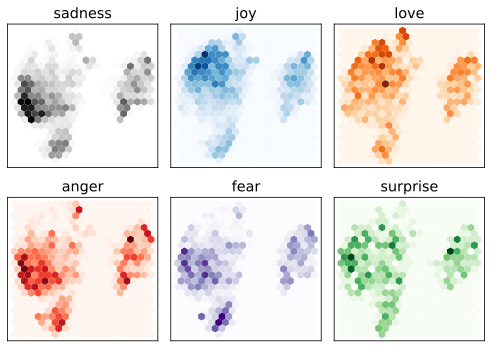

In [46]:
# Plot the 2D UMAP projection for each emotion class separately
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
axes = axes.flatten()
cmaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]
labels = emotions["train"].features["label"].names

for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_emb_sub = df_emb.query(f"label == {i}")
    axes[i].hexbin(df_emb_sub["X"], df_emb_sub["Y"], cmap=cmap,
                   gridsize=20, linewidths=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

> Note: 这些只是在一个低维空间中的投射.  
> 一些类别重叠并不意味着它们在原始空间中就无法分离.  
> 相反，如果它们在投射空间中是可分离的，那么它们在原始空间中也将是可分离的.

从这个图中，我们可以看到一些明显的模式:  
如 `sadness`、`anger` 和 `fear` 等负面情绪都占据着相似的区域，只是分布略有不同.   
另一方面，`joy` 和 `love` 则与负面情绪明显分开，同时也共享着一个相似的空间.   
最后，`surprise` 则散落在各个地方.  
尽管我们可能希望能够有一些分离，但这绝对不是一定的，因为模型并没有经过训练来区分这些情绪.  
它只是通过猜测文本中的 masked words 而隐式学习这些情绪.

现在我们已经对数据集的特征有了一些了解，让我们训练一个模型吧!

### 3.1.5 训练一个 Softmax 分类器

我们发现，尽管有些情绪之间的 hidden state 有所不同，  
但对于其中几种情绪来说并没有明显的界限.  
让我们使用 [Scikit-Learn](https://scikit-learn.org/stable/) 在这些 hidden state 上训练一个分类模型.  
下面我们以 Softmax 回归分类模型进行举例，  
训练这样一个简单模型很快速，而且不需要 GPU.

> Note: Scikit-Learn 的 `LogisticRegression` 默认支持多分类，  
> 检测到标签超过 2 个类时就使用 multinomial (softmax) 模式.  
> 所以虽然是 "Logistic Regression" 这个名字，实际做的是 Softmax 回归.

In [47]:
# Train a logistic regression classifier on the extracted hidden states
# Increase max_iter to guarantee convergence
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)
y_preds = lr_clf.predict(X_valid)
lr_clf.score(X_valid, y_valid)

0.6345

看准确率可能会觉得我们的模型比随机好一点点，  
但因为我们在处理一个不平衡的多类别数据集，实际上效果要好得多.  
我们可以通过将其与简单基准进行比较来检查我们的模型是否有效.  
在 Scikit-Learn 中，有一个 `DummyClassifier`，  
可以用来使用简单的启发式构建分类器，  
比如总是选择最常见的类别或总是随机选择一个类别.  
在这种情况下，效果最好的启发式是总是选择最频繁的类别，  
这样可以获得约 35% 的准确率:

In [48]:
# Compare against a naive baseline that always predicts the majority class
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_valid, y_valid)

0.352

所以，我们带有 DistilBERT embedding 的简单分类器明显比我们的基线更好.  
我们可以通过查看分类器的混淆矩阵进一步调查模型的性能，  
混淆矩阵告诉我们真实标签和预测标签之间的关系:

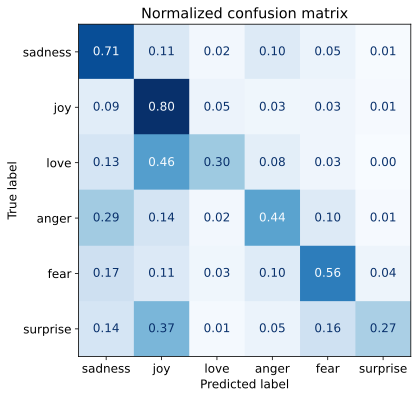

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from pathlib import Path


def plot_confusion_matrix(y_preds, y_true, labels, save_path=None):
    """Plot a normalised confusion matrix for model predictions.

    Args:
        y_preds: Predicted label indices.
        y_true: Ground-truth label indices.
        labels: List of class names for the axis ticks.
        save_path: Optional path to save the figure as PDF (300 dpi).
    """
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(y_preds, y_valid, labels)

我们可以看到，`anger` 和 `fear` 经常会被误解为 `sadness`，  
这与我们在可视化 embedding 时所做的观察相符.  
而 `love` 和 `surprise` 也经常被误解为 `joy`.

### 3.1.6 对比不同的分类器

`#TODO (No.3): 请尝试 Scikit-Learn 中的其他分类模型，对比不同模型的分类效果.`

In [50]:
# evaluate_classifiers(X_train, y_train, X_valid, y_valid, labels)

在接下来的部分中，我们将探讨微调方法，这会带来更优越的分类性能.  
然而，重要的是要注意，这样做需要更多的计算资源，比如 GPU.  
在这种情况下，基于特征的方法可能是传统机器学习和深度学习之间的一个好折中方案.

## 3.2 对 Transformer 进行微调

现在让我们来探讨如何逐步端到端地优化一个 Transformer.  
通过微调的方法，我们不使用 hidden state 作为固定特征，而是训练它们.   
这需要分类头是可微分的，这就是为什么这种方法通常使用神经网络进行分类的原因.

<img alt="encoder-tuning" width=800 caption="When using the fine-tuning approach the whole DistilBERT model is trained along with the classification head" src="images/chapter02_encoder-fine-tuning.png" id="encoder-tuning"/>

训练用来作为分类模型输入的 hidden state 将有助于避免使用可能不适合分类任务的数据的问题.  
相反，在训练过程中，初始 hidden state 会适应以减少模型损失，从而提高其性能. 

我们将使用 Transformers 的 `Trainer` API 来简化训练循环.  

### 3.2.1 加载预训练模型

首先我们需要的是一个预训练的 DistilBERT 模型，  
就像我们在基于特征的方法中使用的那个一样.  
唯一的细微修改是我们使用 `AutoModelForSequenceClassification` 模型而不是 `AutoModel`.  
区别在于 `AutoModelForSequenceClassification` 模型在预训练模型输出的顶部有一个分类头，  
可以很容易地与基本模型一起训练.
我们只需要指定模型需要预测多少个标签 (在我们的问题中是 6 个)，  
因为这会决定分类头输出的数量:

In [51]:
# Load DistilBERT with a randomly initialised classification head on top
from transformers import AutoModelForSequenceClassification

NUM_LABELS = 6
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt, num_labels=NUM_LABELS)
         .to(device))

终端的警告信息说明模型的某些部分是随机初始化的.  
这是正常的，因为分类头还没有被训练过.  
接下来的步骤是定义我们将用来在微调过程中评估模型性能的指标.

### 3.2.2 定义性能指标

为了在训练过程中监控性能指标 (metrics)，  
我们需要为 `Trainer` 定义一个 `compute_metrics()` 函数.  
该函数接收一个 `EvalPrediction` 对象 (这是一个命名元组，包含 `predictions` 和 `label_ids` 属性)，  
并需要返回一个字典，将每个指标的名称映射到其值.  
对于我们的应用，我们将计算模型的 $F_1$-score 和 accuracy，方法如下:

In [52]:
from sklearn.metrics import accuracy_score, f1_score


def compute_metrics(pred):
    """Compute accuracy and weighted F1-score for model evaluation.

    Args:
        pred: An EvalPrediction namedtuple with .predictions and .label_ids.

    Returns:
        A dict {"accuracy": float, "f1": float}.
    """
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

有了数据集和性能指标，我们在定义 `Trainer` 类之前只需要处理两件最后的事情:

1. 登录到我们在 Hugging Face Hub 上的帐户.  
   这将允许我们将微调过的模型推送到 Hub 上，并与社区分享.
2. 为训练运行定义所有超参数.

我们将在下一节中完成这些步骤.

### 3.2.3 训练模型

定义训练参数，我们使用 `TrainingArguments` 类.  
这个类存储了大量信息，并且让你对训练和评估有着精细的控制.  
要指定的最重要参数是 `output_dir`，这是训练过程中所有工件的存储位置.  
这里有一个 `TrainingArguments` 的示例:

In [53]:
from transformers import TrainingArguments

BATCH_SIZE = 8
EPOCHS = 10

# Configure training hyperparameters (baseline config)
baseline_dir = "./checkpoints/baseline"
training_args = TrainingArguments(output_dir=baseline_dir,
                                  num_train_epochs=EPOCHS,
                                  learning_rate=1e-4,
                                  per_device_train_batch_size=BATCH_SIZE,
                                  per_device_eval_batch_size=BATCH_SIZE,
                                  weight_decay=0.01,
                                  eval_strategy="epoch",
                                  save_strategy="epoch",
                                  load_best_model_at_end=True,
                                  metric_for_best_model="accuracy",
                                  greater_is_better=True,
                                  save_total_limit=1,
                                  logging_steps=len(
                                      emotions_encoded["train"]) // BATCH_SIZE // EPOCHS,
                                  remove_unused_columns=False,
                                  disable_tqdm=False,
                                  push_to_hub=False,
                                  log_level="error")

在这里我们还设置了批处理大小、学习率和训练周期的数量，并指定在训练结束时加载最佳模型.  
有了这个最后的步骤，我们可以使用 `Trainer` 实例化并对模型进行微调:

In [54]:
from transformers import Trainer

# Instantiate the Trainer and fine-tune the model end-to-end
trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"])
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.542500,0.180798,0.929500,0.929313


KeyboardInterrupt: 

实验日志显示，我们的模型在验证集上的 $F_1$-score 约为 92%，  
相对于基于特征的方法有明显的改进!

我们可以通过计算混淆矩阵来更详细地查看训练指标.  
要可视化混淆矩阵，首先需要获得验证集的预测值.  
`Trainer` 类的 `predict()` 方法返回一些有用的对象，我们可以用于评估.

In [55]:
# Obtain predictions on the validation set
preds_output = trainer.predict(emotions_encoded["validation"])

`predict()` 方法的输出是一个 `PredictionOutput` 对象，  
包含了 `predictions` 和 `label_ids` 的数组，以及我们传递给训练器的指标.  
例如，验证集上的指标可以通过以下方式访问:

In [56]:
# Inspect evaluation metrics on the validation set
preds_output.metrics

{'test_loss': 0.19795361161231995,
 'test_accuracy': 0.925,
 'test_f1': 0.925706612328699,
 'test_runtime': 7.5011,
 'test_samples_per_second': 266.628,
 'test_steps_per_second': 5.599}

它还包含每个类别的原始预测.   
我们可以使用 `np.argmax()` 贪婪地解码预测.  
这将产生预测的标签，并与 Scikit-Learn 模型在基于特征的方法中返回的标签具有相同的格式:

In [57]:
# Decode raw logits into predicted class labels
y_preds = np.argmax(preds_output.predictions, axis=1)

根据预测，我们可以再次绘制混淆矩阵:

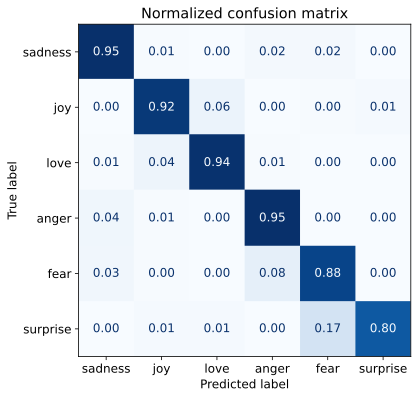

In [58]:
# Visualise the fine-tuned model's confusion matrix and save as PDF
plot_confusion_matrix(y_preds, y_valid, labels,
                      save_path="./figures/finetuned_confusion_matrix.pdf")

这个矩阵更接近理想的对角混淆矩阵.  
`love` 的类别仍然经常被误认为是 `joy`，这似乎很自然.  
`surprise` 也经常被误认为是 `joy`，或与 `fear` 混淆.  
总的来说，模型的性能似乎相当不错，  
但在我们结束之前，让我们深入了解一下我们的模型可能会犯的错误类型.

In [ ]:
#TODO (No.4): Tune hyperparameters (learning rate, batch size, weight decay)
# via a 3x3x3 grid search in parallel across all available GPUs.
# Baseline config from section 3.2.3 is included as a reference.
# Results and analysis plots are saved to ./figures/.
from utils import tune_hyperparameters

tune_hyperparameters(
    model_ckpt=model_ckpt,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"],
    num_labels=NUM_LABELS,
    ckpt_dir="./checkpoints",
    results_dir="./figures",
)

Total experiments: 27
GPUs available: 6, Workers: 6

Starting parallel execution with 6 workers...
Multiprocessing context: spawn

[5] lr=2e-05, bs=8, wd=0.01  ...[1] lr=2e-05, bs=4, wd=0.001  ...[6] lr=2e-05, bs=8, wd=0.1  ...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-strea

[2] lr=2e-05, bs=4, wd=0.01  ...[3] lr=2e-05, bs=4, wd=0.1  ...[4] lr=2e-05, bs=8, wd=0.001  ...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-strea

[7] lr=2e-05, bs=16, wd=0.001  ...[8] lr=2e-05, bs=16, wd=0.01  ...[9] lr=2e-05, bs=16, wd=0.1  ...[10] lr=0.0001, bs=4, wd=0.001  ...[11] lr=0.0001, bs=4, wd=0.01  ...[12] lr=0.0001, bs=4, wd=0.1  ...

/root/snape/Introduction-to-AI-Project-02/.venv/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/root/snape/Introduction-to-AI-Project-02/.venv/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/root/snape/Introduction-to-AI-Project-02/.venv/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/root/snape/Introduction-to-AI-Project-02/.venv/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead 

## 3.3 结果分析

在继续之前，我们应该进一步调查我们模型的预测.  
一个简单而有效的技术是通过模型损失对验证样本进行排序.   
在前向传递标签时，损失会自动计算并返回.   
这里是一个返回损失和预测标签的函数:  

In [ ]:
from torch.nn.functional import cross_entropy


def forward_pass_with_label(batch):
    """Run a forward pass and return per-sample loss and predicted label.

    Args:
        batch: A dict of batched model inputs with keys including
               "input_ids", "attention_mask", and "label".

    Returns:
        A dict with "loss" and "predicted_label" as NumPy arrays.
    """
    # Place model inputs on the same device as the model
    inputs = {k: v.to(device) for k, v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")

    # Return CPU NumPy arrays for compatibility with Dataset.map()
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

再次使用 `map()` 方法，我们可以将这个函数应用到所有样本上，得到损失.

In [ ]:
# Convert dataset back to torch format and compute per-sample loss
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
emotions_encoded["validation"] = emotions_encoded["validation"].map(
    forward_pass_with_label, batched=True, batch_size=16)

最后，我们创建一个包含文本、损失值以及预测 / 真实标签的 `DataFrame`:

In [ ]:
# Build a DataFrame with text, labels, predictions, and loss for error analysis
emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = df_test["predicted_label"].apply(label_int2str)

In [ ]:
#TODO (No.5): 请分析分类错误的样本为什么会被分错，而分类正确的样本为什么会被分对?

让我们首先看一下损失最大的数据样本：

In [ ]:
# Inspect the 10 samples with the highest loss (most misclassified)
df_test.sort_values("loss", ascending=False).head(10)

(TODO: 分析分类错误的样本为什么会被分错)

我们再看看损失最小的数据样本：

In [ ]:
# Inspect the 10 samples with the lowest loss (most correctly classified)
df_test.sort_values("loss", ascending=True).head(10)

(TODO: 分析分类正确的样本为什么会被分对)

## 3.4 保存和分享模型

使用`save_model`方法保存模型参数

In [ ]:
# Save the fine-tuned model weights to disk
trainer.save_model("./model")

我们还可以使用微调过的模型来对新推文进行预测.  
现在我们可以使用 `pipeline()` 函数来使用它.  
首先，让我们加载 pipeline:

In [ ]:
# Load the saved model into a Hugging Face pipeline for inference
from transformers import pipeline

classifier = pipeline("text-classification", model="./model")

使用以下 pipeline 可以直接对任意推文进行情感分类:

In [ ]:
# Test the pipeline on a custom tweet
custom_tweet = "I saw a movie today and it was really good."
preds = classifier(custom_tweet, return_all_scores=True)

我们可以在条形图中绘制每个类别的概率:

In [ ]:
# Plot the predicted probability distribution across all emotion classes
preds_df = pd.DataFrame(preds[0])
plt.bar(labels, 100 * preds_df["score"], color='C0')
plt.title(f'"{custom_tweet}"')
plt.ylabel("Class probability (%)")
plt.show()

In [ ]:
#TODO (No.6): 构造 5 条对抗样本，尽可能的让模型无法正确的判断其情感类别，并试着解释原因